Step 1: Initial Exploration

In [1]:
import pandas as pd
import numpy as np

# Load the data
df = pd.read_csv('recom.csv')

# Understand the structure
#print(df.info())
#print(df.describe())
#print(df.head(20))
print('info:')
print(df.info())
print('describe:')
print(df.describe())
print('head:')
print(df.head(100))
print('shape:')
print(df.shape)
print('isnull:')
print(df.isnull().sum())
print('duplicated:')
print(df.duplicated().sum())

# Key questions to investigate:
#- How many unique customers?
#- How many unique items (ItemKey vs Code_Product)?
#- Distribution of purchases per customer?
#- Distribution of purchases per item?
#- How many missing ItemKey values?
#- Date range and temporal patterns?

info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      50000 non-null  int64  
 1   Main_ID         50000 non-null  object 
 2   Transaction_ID  50000 non-null  object 
 3   Date            50000 non-null  object 
 4   Price           50000 non-null  float64
 5   Code_Product    50000 non-null  float64
 6   Amount          50000 non-null  float64
 7   ItemKey         28597 non-null  float64
dtypes: float64(4), int64(1), object(3)
memory usage: 3.1+ MB
None
describe:
         Unnamed: 0         Price   Code_Product        Amount       ItemKey
count  50000.000000  50000.000000   50000.000000  50000.000000  28597.000000
mean   24999.500000     62.560670   32379.293540      1.232640  20775.740952
std    14433.901067     68.269624   21697.500334      0.749353  16481.882853
min        0.000000      0.500000    5000.500000   

In [2]:
df.head()

,Unnamed: 0,Main_ID,Transaction_ID,Date,Price,Code_Product,Amount,ItemKey
0,0,90fada91,264f7a69,2022-10-07 20:53:49.153,125.0,5002.0,1.0,5002.0
1,1,9006f9ac,45c7d853,2022-09-17 15:54:57.187,19.0,35012.0,1.0,NaN
2,2,32270891,61ad76dd,2022-11-28 13:51:55.667,141.0,5005.0,1.0,5005.0
3,3,97e03e47,41ee09f6,2022-09-12 16:20:22.110,4.5,35078.5,1.0,NaN
4,4,41949228,244fe6d8,2022-10-14 18:53:43.933,129.5,49291.5,5.0,NaN


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Basic Dataset Information
# -----------------------------

print("Number of rows and columns:", df.shape)
print()

print("Unique Customers:", df["Main_ID"].nunique())
print("Unique Transactions:", df["Transaction_ID"].nunique())
print("Unique ItemKeys:", df["ItemKey"].nunique())
print("Unique Code_Product:", df["Code_Product"].nunique())
print()

# -----------------------------
# Missing ItemKey Values
# -----------------------------

missing_itemkey = df["ItemKey"].isnull().sum()

print("Missing ItemKey Values:", missing_itemkey)
print("Percentage Missing:",
      round((missing_itemkey / len(df)) * 100, 2), "%")

Number of rows and columns: (50000, 8)

Unique Customers: 28514
Unique Transactions: 48403
Unique ItemKeys: 152
Unique Code_Product: 333

Missing ItemKey Values: 21403
Percentage Missing: 42.81 %


count    28514.000000
mean         1.753525
std          2.306502
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         51.000000
dtype: float64


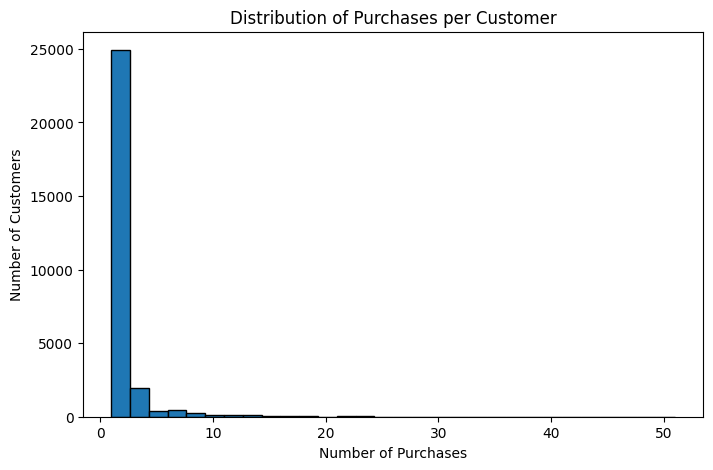

In [4]:
# Count purchases made by each customer
customer_purchases = df.groupby("Main_ID").size()

print(customer_purchases.describe())

plt.figure(figsize=(8,5))
plt.hist(customer_purchases, bins=30, edgecolor="black")
plt.title("Distribution of Purchases per Customer")
plt.xlabel("Number of Purchases")
plt.ylabel("Number of Customers")
plt.show()

count     152.000000
mean      188.138158
std       457.303601
min         1.000000
25%         7.750000
50%        33.500000
75%       156.250000
max      3814.000000
dtype: float64


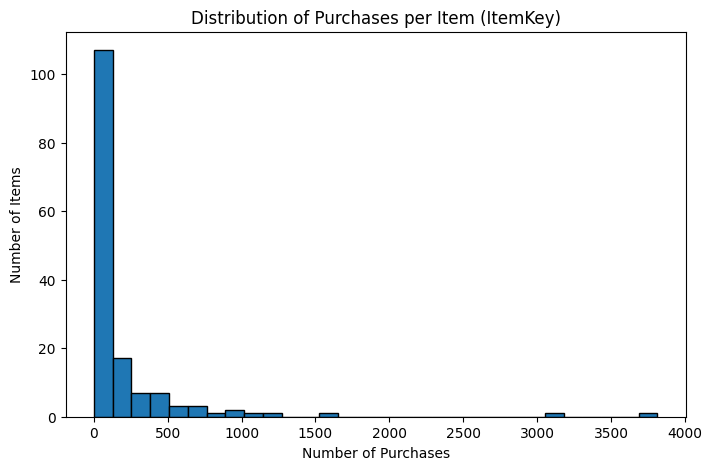

In [5]:
# Count purchases for each ItemKey
item_purchases = df.groupby("ItemKey").size()

print(item_purchases.describe())

plt.figure(figsize=(8,5))
plt.hist(item_purchases, bins=30, edgecolor="black")
plt.title("Distribution of Purchases per Item (ItemKey)")
plt.xlabel("Number of Purchases")
plt.ylabel("Number of Items")
plt.show()

count     333.000000
mean      150.150150
std       494.432919
min         1.000000
25%         4.000000
50%        15.000000
75%        83.000000
max      4862.000000
dtype: float64


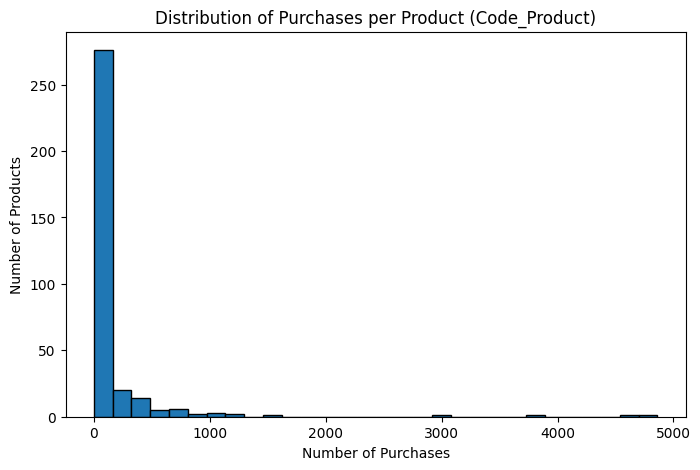

In [6]:
product_purchases = df.groupby("Code_Product").size()

print(product_purchases.describe())

plt.figure(figsize=(8,5))
plt.hist(product_purchases, bins=30, edgecolor="black")
plt.title("Distribution of Purchases per Product (Code_Product)")
plt.xlabel("Number of Purchases")
plt.ylabel("Number of Products")
plt.show()

Earliest Transaction: 2022-08-26 00:00:14.643000
Latest Transaction: 2022-12-03 02:14:57.983000


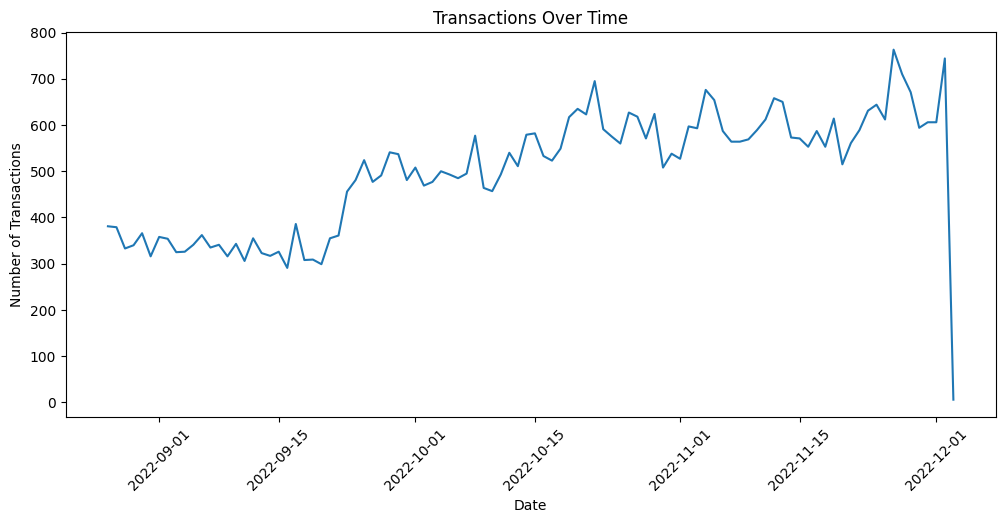

In [7]:
# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"])

print("Earliest Transaction:", df["Date"].min())
print("Latest Transaction:", df["Date"].max())

# Transactions over time
transactions_per_day = df.groupby(df["Date"].dt.date).size()

plt.figure(figsize=(12,5))
transactions_per_day.plot()
plt.title("Transactions Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.show()

In [8]:
print(df[["Code_Product", "ItemKey"]].head(20))

    Code_Product  ItemKey
0         5002.0   5002.0
1        35012.0      NaN
2         5005.0   5005.0
3        35078.5      NaN
4        49291.5      NaN
5        49291.5      NaN
6         5012.0   5012.0
7        49292.0      NaN
8        49292.0      NaN
9         5011.5   5011.5
10        5025.0   5025.0
11       10032.5  10032.5
12        5009.0   5009.0
13       35096.5      NaN
14       40069.5  40069.5
15       45004.0  45004.0
16       48504.5      NaN
17       25003.5  25003.5
18       49291.5      NaN
19        5009.0   5009.0


In [9]:
mapping = df.groupby("Code_Product")["ItemKey"].nunique()

mapping.value_counts()

,count
ItemKey,
0,181
1,152


In [10]:
df.groupby("ItemKey")["Code_Product"].nunique().sort_values(ascending=False).head(20)

,Code_Product
ItemKey,
5000.5,1
5001.0,1
5001.5,1
5002.0,1
5002.5,1
5003.0,1
5004.0,1
5004.5,1
5005.0,1


In [11]:
same = (df["Code_Product"] == df["ItemKey"]) | (df["ItemKey"].isna())

print("All non-missing ItemKeys equal Code_Product:", same.all())

All non-missing ItemKeys equal Code_Product: True


In [12]:
#this will show me how many transactions these users have
customer_purchase_counts = df.groupby("Main_ID").size()

print(customer_purchase_counts.value_counts().sort_index())

1     21271
2      3647
3      1258
4       718
5       399
6       275
7       189
8       143
9        94
10       99
11       66
12       53
13       48
14       44
15       39
16       21
17       27
18       20
19       16
20       15
21        7
22       13
23       10
24        8
25        5
26        5
27        4
28        3
29        2
30        1
31        4
32        1
33        1
35        1
36        4
39        1
47        1
51        1
Name: count, dtype: int64


Based on the above results, I don't think I should remove any users. 21271 users have only 1 transaction and that is about 75% of the dataset if I removed them

In [13]:
# Create the user-item interaction matrix using purchase frequency

user_item_matrix = df.pivot_table(
    index="Main_ID",
    columns="Code_Product",
    values="Transaction_ID",
    aggfunc="count",
    fill_value=0
)

print("User-Item Matrix Shape:", user_item_matrix.shape)
user_item_matrix.head()


User-Item Matrix Shape: (28514, 333)


Code_Product,5000.5,5001.0,5001.5,5002.0,5002.5,5003.0,5004.0,5004.5,5005.0,5007.0,...,200035.5,200037.0,200037.5,200038.0,200038.5,200045.5,200046.0,200046.5,200047.0,350027.5
Main_ID,,,,,,,,,,,,,,,,,,,,,
00024de6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
00084856,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0008e848,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
00096930,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
000c66b7,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [14]:
print("Number of customers:", user_item_matrix.shape[0])
print("Number of products:", user_item_matrix.shape[1])

print("\nFirst five rows:")
display(user_item_matrix.head())

print("\nMatrix sparsity:")
non_zero = (user_item_matrix > 0).sum().sum()
total = user_item_matrix.size

print(f"Non-zero entries: {non_zero:,}")
print(f"Total entries: {total:,}")
print(f"Sparsity: {(1 - non_zero / total) * 100:.2f}%")

Number of customers: 28514
Number of products: 333

First five rows:


Code_Product,5000.5,5001.0,5001.5,5002.0,5002.5,5003.0,5004.0,5004.5,5005.0,5007.0,...,200035.5,200037.0,200037.5,200038.0,200038.5,200045.5,200046.0,200046.5,200047.0,350027.5
Main_ID,,,,,,,,,,,,,,,,,,,,,
00024de6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
00084856,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0008e848,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
00096930,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
000c66b7,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



Matrix sparsity:
Non-zero entries: 45,901
Total entries: 9,495,162
Sparsity: 99.52%


In [15]:
#train test split
from collections import defaultdict

train_df = []
test_items = defaultdict(list)

for customer, group in df.groupby("Main_ID"):
    if len(group) > 1:
        test_row = group.sample(1, random_state=42)
        train_rows = group.drop(test_row.index)

        train_df.append(train_rows)
        test_items[customer] = test_row["Code_Product"].tolist()
    else:
        train_df.append(group)

train_df = pd.concat(train_df)

4.2 Part 2: Implicit Rating Strategy

In [16]:
#same as the user_item_matrix
frequency_matrix = df.pivot_table(
    index="Main_ID",
    columns="Code_Product",
    values="Transaction_ID",
    aggfunc="count",
    fill_value=0
)

In [17]:
df["TotalSpent"] = df["Price"] * df["Amount"]

spending_matrix = df.pivot_table(
    index="Main_ID",
    columns="Code_Product",
    values="TotalSpent",
    aggfunc="sum",
    fill_value=0
)

4.3 Part 3: Comparative Implementation

In [18]:
# Most frequently purchased products in the training data
# Popularity-Based Baseline
popular_items = (
    train_df.groupby("Code_Product")
    .size()
    .sort_values(ascending=False)
    .index
    .tolist()
)

def recommend_popularity(user_id, n=5):
    user_items = set(train_df[train_df["Main_ID"] == user_id]["Code_Product"])

    recommendations = [
        item for item in popular_items
        if item not in user_items
    ]

    return recommendations[:n]

In [19]:
#Rebuild User-Item Matrix from train_df: Use only training data so we avoid test leakage.

train_matrix = train_df.pivot_table(
    index="Main_ID",
    columns="Code_Product",
    values="Transaction_ID",
    aggfunc="count",
    fill_value=0
)

In [ ]:
#caused crash
#User-Based Collaborative Filtering
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

user_similarity = cosine_similarity(train_matrix)

user_similarity_df = pd.DataFrame(
    user_similarity,
    index=train_matrix.index,
    columns=train_matrix.index
)

def recommend_user_based(user_id, n_similar=10, n_recommendations=5):
    if user_id not in train_matrix.index:
        return recommend_popularity(user_id, n_recommendations)

    similar_users = (
        user_similarity_df[user_id]
        .drop(user_id)
        .sort_values(ascending=False)
        .head(n_similar)
    )

    scores = {}
    user_items = set(train_matrix.loc[user_id][train_matrix.loc[user_id] > 0].index)

    for similar_user, similarity_score in similar_users.items():
        similar_user_items = train_matrix.loc[similar_user]

        for item, rating in similar_user_items[similar_user_items > 0].items():
            if item not in user_items:
                scores[item] = scores.get(item, 0) + similarity_score * rating

    ranked_items = sorted(scores.items(), key=lambda x: x[1], reverse=True)

    recommendations = [item for item, score in ranked_items]

    if len(recommendations) < n_recommendations:
        for item in popular_items:
            if item not in user_items and item not in recommendations:
                recommendations.append(item)

    return recommendations[:n_recommendations]

In [ ]:
#caused crash
#Item-Based Collaborative Filtering
item_similarity = cosine_similarity(train_matrix.T)

item_similarity_df = pd.DataFrame(
    item_similarity,
    index=train_matrix.columns,
    columns=train_matrix.columns
)



NameError: name 'cosine_similarity' is not defined

In [ ]:
# caused crash
def recommend_item_based(user_id, n_recommendations=5):
    if user_id not in train_matrix.index:
        return recommend_popularity(user_id, n_recommendations)

    user_ratings = train_matrix.loc[user_id]
    purchased_items = user_ratings[user_ratings > 0]

    scores = {}
    user_items = set(purchased_items.index)

    for item, rating in purchased_items.items():
        similar_items = item_similarity_df[item].drop(item)

        for similar_item, similarity_score in similar_items.items():
            if similar_item not in user_items:
                scores[similar_item] = scores.get(similar_item, 0) + similarity_score * rating

    ranked_items = sorted(scores.items(), key=lambda x: x[1], reverse=True)

    recommendations = [item for item, score in ranked_items]

    if len(recommendations) < n_recommendations:
        for item in popular_items:
            if item not in user_items and item not in recommendations:
                recommendations.append(item)

    return recommendations[:n_recommendations]

In [20]:
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

# Make sparse version of train matrix
train_sparse = csr_matrix(train_matrix.values)

# Item-item similarity: transpose so rows are products
item_similarity = cosine_similarity(train_sparse.T, dense_output=True)

item_similarity_df = pd.DataFrame(
    item_similarity,
    index=train_matrix.columns,
    columns=train_matrix.columns
)

In [21]:
def recommend_item_based(user_id, n_recommendations=5):
    if user_id not in train_matrix.index:
        return recommend_popularity(user_id, n_recommendations)

    user_ratings = train_matrix.loc[user_id]
    purchased_items = user_ratings[user_ratings > 0]

    scores = {}
    user_items = set(purchased_items.index)

    for item, rating in purchased_items.items():
        similar_items = item_similarity_df[item].drop(item).sort_values(ascending=False).head(20)

        for similar_item, similarity_score in similar_items.items():
            if similar_item not in user_items:
                scores[similar_item] = scores.get(similar_item, 0) + similarity_score * rating

    ranked_items = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    recommendations = [item for item, score in ranked_items]

    if len(recommendations) < n_recommendations:
        for item in popular_items:
            if item not in user_items and item not in recommendations:
                recommendations.append(item)

    return recommendations[:n_recommendations]

In [22]:
sample_user = train_matrix.index[0]

print("User:", sample_user)
print("Popularity:", recommend_popularity(sample_user, 5))
print("Item-Based CF:", recommend_item_based(sample_user, 5))

User: 00024de6
Popularity: [49292.0, 49291.5, 5000.5, 45004.0, 10013.0]
Item-Based CF: [35049.0, 35001.0, 35096.5, 30026.5, 35079.5]


In [24]:
# Popularity-Based Baseline
# Recommend the most frequently purchased products in the training data

popular_items = (
    train_df.groupby("Code_Product")
    .size()
    .sort_values(ascending=False)
    .index
    .tolist()
)

print("Top 10 most popular products:")
print(popular_items[:10])

Top 10 most popular products:
[49292.0, 49291.5, 5000.5, 45004.0, 10013.0, 5009.0, 48513.0, 25003.0, 48504.5, 5011.5]


In [25]:
def recommend_popularity(user_id, n_recommendations=5):
    # Products this user already bought in training data
    user_items = set(
        train_df[train_df["Main_ID"] == user_id]["Code_Product"]
    )

    # Recommend popular products the user has not already bought
    recommendations = [
        item for item in popular_items
        if item not in user_items
    ]

    return recommendations[:n_recommendations]

In [26]:
sample_user = train_df["Main_ID"].iloc[0]

print("Sample User:", sample_user)
print("Popularity Recommendations:", recommend_popularity(sample_user, 5))

Sample User: 00024de6
Popularity Recommendations: [49292.0, 49291.5, 5000.5, 45004.0, 10013.0]


new item based rec

In [27]:
import pandas as pd
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity

In [28]:
# Frequency-based user-item matrix from training data only

train_matrix = train_df.pivot_table(
    index="Main_ID",
    columns="Code_Product",
    values="Transaction_ID",
    aggfunc="count",
    fill_value=0
)

print("Training matrix shape:", train_matrix.shape)

Training matrix shape: (28514, 327)


In [29]:
# Convert dense DataFrame to sparse matrix
train_sparse = csr_matrix(train_matrix.values)

# Transpose so rows represent products instead of customers
item_similarity = cosine_similarity(
    train_sparse.T,
    dense_output=True
)

# Store similarities in a DataFrame
item_similarity_df = pd.DataFrame(
    item_similarity,
    index=train_matrix.columns,
    columns=train_matrix.columns
)

print("Item similarity matrix shape:", item_similarity_df.shape)

Item similarity matrix shape: (327, 327)


In [30]:
def recommend_item_based(
    user_id,
    n_recommendations=5,
    n_similar_items=20
):
    """
    Recommend products based on items the customer previously purchased.

    Parameters:
        user_id: Customer ID
        n_recommendations: Number of products to recommend
        n_similar_items: Number of similar products considered
                         for each previously purchased item
    """

    # If the customer is not in training data,
    # use the popularity baseline as a fallback
    if user_id not in train_matrix.index:
        return recommend_popularity(
            user_id,
            n_recommendations
        )

    # Get this customer's purchase-frequency ratings
    user_ratings = train_matrix.loc[user_id]

    # Keep only products the customer purchased
    purchased_items = user_ratings[user_ratings > 0]

    # Set of products already purchased
    user_items = set(purchased_items.index)

    # Dictionary for accumulating recommendation scores
    scores = {}

    for item, rating in purchased_items.items():

        # Find the most similar products to this purchased item
        similar_items = (
            item_similarity_df[item]
            .drop(item)
            .sort_values(ascending=False)
            .head(n_similar_items)
        )

        for similar_item, similarity_score in similar_items.items():

            # Do not recommend something already purchased
            if similar_item not in user_items:

                # Weight similarity by purchase frequency
                weighted_score = similarity_score * rating

                scores[similar_item] = (
                    scores.get(similar_item, 0)
                    + weighted_score
                )

    # Rank products by their final recommendation score
    ranked_items = sorted(
        scores.items(),
        key=lambda x: x[1],
        reverse=True
    )

    recommendations = [
        item for item, score in ranked_items
    ]

    # Popularity fallback if item-based CF produces too few results
    if len(recommendations) < n_recommendations:
        for item in popular_items:
            if (
                item not in user_items
                and item not in recommendations
            ):
                recommendations.append(item)

            if len(recommendations) >= n_recommendations:
                break

    return recommendations[:n_recommendations]

In [31]:
sample_user = train_matrix.index[0]

print("Sample user:", sample_user)

print(
    "Products already purchased:",
    train_matrix.loc[sample_user][
        train_matrix.loc[sample_user] > 0
    ].index.tolist()
)

print(
    "Item-based recommendations:",
    recommend_item_based(
        sample_user,
        n_recommendations=5
    )
)

Sample user: 00024de6
Products already purchased: [35097.0]
Item-based recommendations: [35049.0, 35001.0, 35096.5, 30026.5, 35079.5]


In [32]:
sample_product = train_matrix.columns[0]

print("Product:", sample_product)

display(
    item_similarity_df[sample_product]
    .drop(sample_product)
    .sort_values(ascending=False)
    .head(10)
)

Product: 5000.5


,5000.5
Code_Product,
25003.0,0.218823
48513.0,0.203925
45004.0,0.202923
10013.0,0.202770
49291.5,0.202761
5009.0,0.202369
10003.0,0.200076
49292.0,0.187194
10015.0,0.184568
